# Topic & Keyword Extraction — Revolut Help Articles

Goal: understand **what the knowledge base is about** so the next step (eval **question generation**) can iterate over a structured topic map.

**Core:** [BERTopic](https://maartengr.github.io/BERTopic/) = local embeddings → UMAP → HDBSCAN → c-TF-IDF keywords, with an optional LLM layer for human-readable topic labels.

**Approach (kept simple):**
1. Embed `title + content_text` locally with `BAAI/bge-large-en-v1.5` (GPU).
2. **Sweep `min_topic_size`** and dump every grid point so the granularity choice is data-driven, not guessed.
3. Fully post-process **one or more chosen granularities** — fit, reduce outliers, LLM-label, export.
4. Explore articles that span two topics (ambiguous / hard retrieval cases).
5. Export CSVs + per-article keywords + visualizations for downstream question generation.

**Outputs** (under `../output/`):
- `sweep/min_topic_size_<k>/` — raw clusters + assignments for **every** grid point (manual inspection).
- `mts_<k>/` — full export per **chosen** granularity: `topics.csv`, `article_topics.csv`/`.json`, `ambiguous_articles.csv`, `barchart.html`, `documents.html`.
- `article_keywords.csv` — per-article KeyBERT keywords (granularity-independent, shared).

## 0. Config

All knobs in one place. The key is loaded from the repo-root `.env` (gitignored). Without a key the notebook falls back to keyword-based labels and still runs end-to-end.

In [2]:
import os
from pathlib import Path
from dotenv import load_dotenv, find_dotenv

# Load .env from the repo root (walks up from the notebook's cwd).
load_dotenv(find_dotenv())

# --- paths ---
DATA_PATH = Path("../data/revolut_help_articles.jsonl")
OUTPUT_DIR = Path("../output")
OUTPUT_DIR.mkdir(exist_ok=True)

# --- embeddings (local, GPU) ---
EMBED_MODEL = "BAAI/bge-large-en-v1.5"  # English. Swap to "BAAI/bge-m3" for multilingual.
DEVICE = "cuda"                          # set "cpu" if no GPU

# --- LLM labels via OpenRouter (OpenAI-compatible) ---
OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY", "")
OPENROUTER_BASE_URL = "https://openrouter.ai/api/v1"
LLM_MODEL = "qwen/qwen3.6-27b"          # dense 27B. Alt MoE: "qwen/qwen3.6-35b-a3b"

# --- topic-granularity sweep ---
MIN_TOPIC_SIZE_GRID = [2, 3, 5, 8, 10, 15, 20, 30]
OUTLIER_BUDGET = 0.20                    # max acceptable pre-reduction -1 share
TOP_N_WORDS = 10                         # keywords per topic

# --- vectorizer / reproducibility ---
NGRAM_RANGE = (1, 2)
MIN_DF = 2
RANDOM_STATE = 42

print(f"Data: {DATA_PATH.resolve()}")
print(f"LLM labels: {'ENABLED via OpenRouter (' + LLM_MODEL + ')' if OPENROUTER_API_KEY else 'DISABLED (keyword fallback)'}")

Data: /home/nadirbekov/repo/shvm-ai-evals/Session1_hw/data/revolut_help_articles.jsonl
LLM labels: ENABLED via OpenRouter (qwen/qwen3.6-27b)


## 1. Load articles

Same load pattern as `faq_rag_chatbot.ipynb`. We embed `title + content_text` so the title contributes to the topic signal.

In [3]:
import json

articles = []
with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        articles.append(json.loads(line))

titles = [a["title"] for a in articles]
docs = [f"{a['title']}\n\n{a['content_text']}" for a in articles]

print(f"Loaded {len(docs)} articles")
print("Example title:", titles[0])

Loaded 786 articles
Example title: How can I see my cashflow analytics?


## 2. Quick EDA

count     786.0
mean     1209.0
std       664.0
min        75.0
25%       678.0
50%      1118.0
75%      1580.0
max      4668.0
dtype: float64


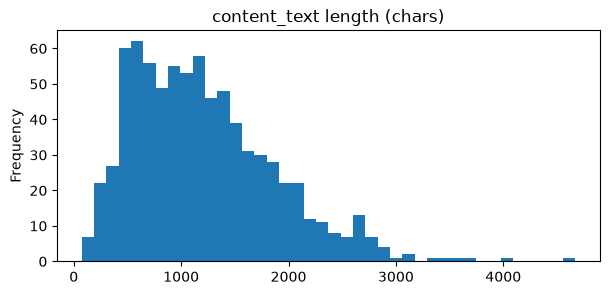

In [4]:
import pandas as pd

lengths = pd.Series([len(a["content_text"]) for a in articles])
print(lengths.describe().round(0))
lengths.plot(kind="hist", bins=40, title="content_text length (chars)", figsize=(7, 3));

## 3. Embeddings

Compute once with `bge-large-en-v1.5` on GPU and reuse for the sweep, the final models, and KeyBERT — all share the same vector space.

In [5]:
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer(EMBED_MODEL, device=DEVICE)
embeddings = embed_model.encode(
    docs,
    normalize_embeddings=True,
    show_progress_bar=True,
    batch_size=64,
)
print("embeddings:", embeddings.shape)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

embeddings: (786, 1024)


## 4. Sweep topic granularity & dump every grid point

We never hard-set `nr_topics` — HDBSCAN discovers the count. The one knob is `min_topic_size` (= HDBSCAN `min_cluster_size`). We sweep it and score each run by:

- **#topics** — how many themes emerge
- **% outliers** — share of docs HDBSCAN labels `-1` (noise: embeddings in low-density regions). `count(topic==-1) / N`. Lower = more coverage.
- **coherence (c_v)** — do a topic's top words co-occur meaningfully (gensim). Higher = better. ⚠️ Trivially high when there are only 2–3 huge topics, so don't pick on coherence alone.
- **diversity** — fraction of unique words across all topics' top-N. Higher = less redundant topics.

Each grid point's raw clusters + article assignments are written to `../output/sweep/min_topic_size_<k>/` so you can eyeball them and choose the granularities to fully export below.

In [6]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

# Tokenized docs for gensim coherence (built once, reused across the sweep).
analyzer = CountVectorizer(stop_words="english", ngram_range=NGRAM_RANGE).build_analyzer()
tokenized_docs = [analyzer(d) for d in docs]
dictionary = Dictionary(tokenized_docs)


def build_model(min_topic_size, representation_model=None):
    """BERTopic with fixed UMAP/vectorizer; only min_cluster_size varies."""
    umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0,
                      metric="cosine", random_state=RANDOM_STATE)
    hdbscan_model = HDBSCAN(min_cluster_size=min_topic_size, metric="euclidean",
                            cluster_selection_method="eom", prediction_data=True)
    vectorizer_model = CountVectorizer(stop_words="english", ngram_range=NGRAM_RANGE, min_df=MIN_DF)
    return BERTopic(
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        representation_model=representation_model,
        top_n_words=TOP_N_WORDS,
        calculate_probabilities=False,
        verbose=False,
    )


def coherence_cv(model, topics):
    """Mean c_v coherence over non-outlier topics."""
    topic_words = [[w for w, _ in model.get_topic(t)][:TOP_N_WORDS]
                   for t in sorted(set(topics)) if t != -1]
    topic_words = [tw for tw in topic_words if len(tw) >= 2]
    if not topic_words:
        return float("nan")
    cm = CoherenceModel(topics=topic_words, texts=tokenized_docs,
                        dictionary=dictionary, coherence="c_v")
    return cm.get_coherence()


def diversity(model, topics):
    """Fraction of unique words across all topics' top-N."""
    words = [w for t in sorted(set(topics)) if t != -1
             for w, _ in model.get_topic(t)[:TOP_N_WORDS]]
    return len(set(words)) / len(words) if words else float("nan")

In [7]:
SWEEP_DIR = OUTPUT_DIR / "sweep"

rows = []
for mts in MIN_TOPIC_SIZE_GRID:
    model = build_model(mts)
    topics, _ = model.fit_transform(docs, embeddings)
    n_outliers = sum(1 for t in topics if t == -1)
    rows.append({
        "min_topic_size": mts,
        "n_topics": len(set(topics)) - (1 if -1 in topics else 0),
        "pct_outliers": round(n_outliers / len(topics), 3),
        "coherence_cv": round(coherence_cv(model, topics), 4),
        "diversity": round(diversity(model, topics), 3),
    })
    print(f"  min_topic_size={mts:>2} -> {rows[-1]['n_topics']} topics, "
          f"{rows[-1]['pct_outliers']:.0%} outliers, c_v={rows[-1]['coherence_cv']}")

    # Dump raw clusters + assignments so every grid point is inspectable by hand.
    d = SWEEP_DIR / f"min_topic_size_{mts}"
    d.mkdir(parents=True, exist_ok=True)
    ti = model.get_topic_info()
    pd.DataFrame({
        "topic_id": ti["Topic"],
        "size": ti["Count"],
        "name": ti["Name"],
        "keywords": [", ".join(w for w, _ in model.get_topic(t)[:TOP_N_WORDS]) if t != -1 else ""
                     for t in ti["Topic"]],
    }).to_csv(d / "topics.csv", index=False)
    pd.DataFrame({"title": titles, "topic_id": topics}).to_csv(d / "article_topics.csv", index=False)

sweep = pd.DataFrame(rows)
print(f"\nPer-grid dumps in {SWEEP_DIR}/min_topic_size_*/")
sweep

  min_topic_size= 2 -> 107 topics, 14% outliers, c_v=0.5653
  min_topic_size= 3 -> 71 topics, 14% outliers, c_v=0.5996
  min_topic_size= 5 -> 47 topics, 19% outliers, c_v=0.6218
  min_topic_size= 8 -> 28 topics, 28% outliers, c_v=0.6555
  min_topic_size=10 -> 3 topics, 0% outliers, c_v=0.7918
  min_topic_size=15 -> 3 topics, 0% outliers, c_v=0.7918
  min_topic_size=20 -> 2 topics, 2% outliers, c_v=0.8086
  min_topic_size=30 -> 2 topics, 2% outliers, c_v=0.8086

Per-grid dumps in ../output/sweep/min_topic_size_*/


,min_topic_size,n_topics,pct_outliers,coherence_cv,diversity
0,2,107,0.137,0.5653,0.772
1,3,71,0.142,0.5996,0.792
2,5,47,0.190,0.6218,0.791
3,8,28,0.276,0.6555,0.846
4,10,3,0.000,0.7918,0.933
5,15,3,0.000,0.7918,0.933
6,20,2,0.022,0.8086,0.950
7,30,2,0.022,0.8086,0.950


In [8]:
import plotly.express as px

# Pareto view: coherence vs % outliers, point size = #topics, color = min_topic_size.
fig = px.scatter(sweep, x="pct_outliers", y="coherence_cv", size="n_topics",
                 color="min_topic_size", text="min_topic_size",
                 title="Granularity trade-off: coherence vs outliers (size = #topics)")
fig.add_vline(x=OUTLIER_BUDGET, line_dash="dash", annotation_text="outlier budget")
fig.update_traces(textposition="top center")
fig.show()

## 5. Post-process chosen granularities

The sweep + the per-grid dumps in `../output/sweep/` show the trade-off. Pick **one or more** `min_topic_size` values to fully post-process and export. Each gets its own `../output/mts_<k>/` folder (topic table, article→topic mapping, ambiguous articles, visualizations).

> Tip: coherence peaks at 2–3 giant topics, which is useless for question generation. For a usable theme map, smaller `min_topic_size` (more topics) is usually what you want — e.g. `5` (~47 topics) or `8` (~28 topics).

In [9]:
# === EDIT ME ===============================================================
# Granularities to fully post-process & export (one ../output/mts_<k>/ each).
# Inspect ../output/sweep/* and the table above, then set these.
CHOSEN_MIN_TOPIC_SIZES = [3, 5, 8, 15]
# ===========================================================================
print("Will export:", CHOSEN_MIN_TOPIC_SIZES)

Will export: [3, 5, 8, 15]


In [10]:
import openai

def label_topics_llm(model, verbose=True):
    """Short LLM label per topic via OpenRouter. One call per topic.

    Robust to None/empty content (which crashes BERTopic's built-in OpenAI
    representation) and to API errors -> falls back to the c-TF-IDF keyword name.
    """
    info = model.get_topic_info()
    fallback = dict(zip(info["Topic"], info["Name"]))
    if not OPENROUTER_API_KEY:
        return fallback

    client = openai.OpenAI(base_url=OPENROUTER_BASE_URL, api_key=OPENROUTER_API_KEY)
    rep_docs = dict(zip(info["Topic"], info["Representative_Docs"]))
    labels = {}
    for t in info["Topic"]:
        if t == -1:
            labels[t] = "Outliers"
            continue
        keywords = ", ".join(w for w, _ in model.get_topic(t)[:TOP_N_WORDS])
        examples = "\n".join(d[:500] for d in rep_docs.get(t, [])[:3])
        prompt = (
            "Topic from Revolut help articles.\n"
            f"Keywords: {keywords}\n\n"
            f"Representative articles:\n{examples}\n\n"
            "Give a short, specific topic label (max 5 words) describing what users ask about. "
            "Return only the label, no quotes or punctuation."
        )
        try:
            resp = client.chat.completions.create(
                model=LLM_MODEL,
                messages=[{"role": "user", "content": prompt}],
                temperature=0,
            )
            content = resp.choices[0].message.content
            labels[t] = content.strip() if content and content.strip() else fallback[t]
        except Exception as e:
            if verbose:
                print(f"  topic {t}: LLM failed ({e}) - keyword fallback")
            labels[t] = fallback[t]
    return labels

print("label_topics_llm ready" + ("" if OPENROUTER_API_KEY else " (no key -> keyword fallback)"))

label_topics_llm ready


### Per-article keywords (shared)

KeyBERT keywords are independent of topic granularity, so compute them **once** and reuse for every size. Same embedding model + MMR for diverse, grounded keywords.

In [11]:
from keybert import KeyBERT

kw_model = KeyBERT(model=embed_model)
keywords_per_doc = kw_model.extract_keywords(
    docs, keyphrase_ngram_range=(1, 2), stop_words="english",
    use_mmr=True, diversity=0.5, top_n=5,
)
article_keywords = pd.DataFrame({
    "title": titles,
    "keywords": [", ".join(kw for kw, _ in kws) for kws in keywords_per_doc],
})
article_keywords.to_csv(OUTPUT_DIR / "article_keywords.csv", index=False)
print(f"Wrote {OUTPUT_DIR / 'article_keywords.csv'} ({len(article_keywords)} rows) - shared across all sizes")
article_keywords.head()

Wrote ../output/article_keywords.csv (786 rows) - shared across all sizes


,title,keywords
0,How can I see my cashflow analytics?,"cashflow widget, track revolut, tap analytics,..."
1,How can I see my spending and income analytics?,"revolut app, view spending, income widget, ana..."
2,How can I see my total wealth analytics?,"revolut custom, overview assets, analytics tot..."
3,How do I add a custom asset to my total wealth...,"asset total, edit custom, tap add, value refre..."
4,How to assign and adjust categories,"transaction category, assigns category, update..."


### Pipeline per granularity

`run_topic_pipeline(mts)` fits the final model, reduces outliers, LLM-labels each topic, and writes every artifact into `../output/mts_<k>/`. Labels are added **after** fitting (not via BERTopic's representation layer) so the LLM is called exactly once per final topic — never re-called during `reduce_outliers`.

In [ ]:
import numpy as np

def run_topic_pipeline(mts):
    """Fit -> reduce outliers -> LLM-label -> export all artifacts for one min_topic_size."""
    outdir = OUTPUT_DIR / f"mts_{mts}"
    outdir.mkdir(parents=True, exist_ok=True)

    # 1. Fit (plain c-TF-IDF; labels added afterward).
    model = build_model(mts)
    topics, probs = model.fit_transform(docs, embeddings)

    # 2. Reduce outliers so every article gets a real topic.
    before = sum(1 for t in topics if t == -1)
    topics = model.reduce_outliers(docs, topics, strategy="c-tf-idf")
    model.update_topics(docs, topics=topics,
                        vectorizer_model=CountVectorizer(stop_words="english",
                                                         ngram_range=NGRAM_RANGE, min_df=MIN_DF))

    # 3. LLM labels (robust to None / errors).
    label_by_topic = label_topics_llm(model)

    info = model.get_topic_info()

    def keywords_for(t):
        return ", ".join(w for w, _ in model.get_topic(t)[:TOP_N_WORDS]) if t != -1 else ""

    rep_title = {}
    for t, doc_list in zip(info["Topic"], info["Representative_Docs"]):
        rep_title[t] = [titles[docs.index(dd)] for dd in doc_list if dd in docs][:3]

    # 4a. Topic table
    topics_df = pd.DataFrame({
        "topic_id": info["Topic"],
        "llm_label": [label_by_topic.get(t, "") for t in info["Topic"]],
        "keywords": [keywords_for(t) for t in info["Topic"]],
        "size": info["Count"],
        "representative_titles": [" | ".join(rep_title.get(t, [])) for t in info["Topic"]],
    })
    topics_df.to_csv(outdir / "topics.csv", index=False)

    # 4b. Article -> topic
    max_probs = probs if probs is not None and probs.ndim == 1 else [None] * len(docs)
    article_topics = pd.DataFrame({
        "title": titles,
        "topic_id": topics,
        "llm_label": [label_by_topic.get(t, "") for t in topics],
        "probability": [round(float(p), 4) if p is not None else None for p in max_probs],
    })
    article_topics.to_csv(outdir / "article_topics.csv", index=False)
    article_topics.to_json(outdir / "article_topics.json", orient="records", indent=2, force_ascii=False)

    # 4c. Ambiguous (two-topic) articles via per-doc topic distribution.
    topic_distr, _ = model.approximate_distribution(docs, window=8, stride=4)
    top2 = np.argsort(-topic_distr, axis=1)[:, :2]
    rng = np.arange(len(docs))
    p1,   = topic_distr[rng, top2[:, 0]], topic_distr[rng, top2[:, 1]]
    ambiguous = pd.DataFrame({
        "title": titles,
        "topic_1": top2[:, 0], "label_1": [label_by_topic.get(int(t), "") for t in top2[:, 0]],
        "topic_2": top2[:, 1], "label_2": [label_by_topic.get(int(t), "") for t in top2[:, 1]],
        "p1": p1.round(3), "p2": p2.round(3), "margin": (p1 - p2).round(3),
    }).sort_values("margin")
    ambiguous = ambiguous[ambiguous["p2"] > 0.1]
    ambiguous.to_csv(outdir / "ambiguous_articles.csv", index=False)

    # 4d. Visualizations to disk (so every size is inspectable without rerunning).
    n_topics = len(set(topics)) - (1 if -1 in topics else 0)
    try:
        model.visualize_barchart(top_n_topics=min(16, n_topics), n_words=8).write_html(outdir / "barchart.html")
        model.visualize_documents(titles, embeddings=embeddings).write_html(outdir / "documents.html")
    except Exception as e:
        print(f"  mts={mts}: viz skipped ({e})")

    print(f"mts={mts}: {n_topics} topics, outliers {before} -> 0, "
          f"{len(ambiguous)} ambiguous -> {outdir}/")
    return {
        "mts": mts, "model": model, "topics": topics, "label_by_topic": label_by_topic,
        "topics_df": topics_df, "article_topics": article_topics,
        "ambiguous": ambiguous, "topic_distr": topic_distr, "n_topics": n_topics,
    }

In [13]:
results = {mts: run_topic_pipeline(mts) for mts in CHOSEN_MIN_TOPIC_SIZES}
print("\nDone. Folders:")
for mts in CHOSEN_MIN_TOPIC_SIZES:
    print(f"  ../output/mts_{mts}/  ->  {results[mts]['n_topics']} topics")

2026-06-21 00:10:44,806 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


mts=3: 71 topics, outliers 112 -> 0, 554 ambiguous -> ../output/mts_3/


2026-06-21 01:19:42,502 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


mts=5: 47 topics, outliers 149 -> 0, 618 ambiguous -> ../output/mts_5/


2026-06-21 02:05:43,605 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


mts=8: 28 topics, outliers 217 -> 0, 628 ambiguous -> ../output/mts_8/


ValueError: No outliers to reduce.

In [16]:
TOPIC_TO_RERUN = 15

# --- Fix: tolerate granularities with zero outliers (e.g. mts=15 -> 3 topics, 0% outliers) ---
from bertopic import BERTopic
if not getattr(BERTopic, "_reduce_outliers_guarded", False):
    _orig_reduce = BERTopic.reduce_outliers
    def reduce_outliers(self, documents, topics, *args, **kwargs):
        if not self._outliers:           # nothing labelled -1 -> leave assignments unchanged
            return list(topics)
        return _orig_reduce(self, documents, topics, *args, **kwargs)
    BERTopic.reduce_outliers = reduce_outliers
    BERTopic._reduce_outliers_guarded = True

# `results` was wiped when the comprehension crashed. 3/5/8 are already exported to disk,
# so only finish the size that failed instead of recomputing everything.
results = globals().get("results", {})
results[TOPIC_TO_RERUN] = run_topic_pipeline(TOPIC_TO_RERUN)

print("\nIn memory:", sorted(results))
print("On disk:   ", [p.name for p in sorted(OUTPUT_DIR.glob('mts_*'))])

2026-06-21 09:51:00,138 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


mts=15: 3 topics, outliers 0 -> 0, 373 ambiguous -> ../output/mts_15/

In memory: [15]
On disk:    ['mts_15', 'mts_3', 'mts_5', 'mts_8']


## 6. Inspect one granularity inline

Everything is on disk per size. Below we render one `PRIMARY` size on screen for a sanity check — change `PRIMARY` to any value in `CHOSEN_MIN_TOPIC_SIZES`.

In [18]:
def load_results_from_disk(mts):
    outdir = OUTPUT_DIR / f"mts_{mts}"
    topics_df      = pd.read_csv(outdir / "topics.csv")
    article_topics = pd.read_csv(outdir / "article_topics.csv")
    ambiguous      = pd.read_csv(outdir / "ambiguous_articles.csv")
    topics         = article_topics["topic_id"].tolist()
    label_by_topic = dict(zip(topics_df["topic_id"], topics_df["llm_label"]))
    n_topics       = len([t for t in set(topics) if t != -1])
    return {
        "mts": mts, "topics": topics, "label_by_topic": label_by_topic,
        "topics_df": topics_df, "article_topics": article_topics,
        "ambiguous": ambiguous, "n_topics": n_topics,
        "model": None,        # not persisted -> visualize_*() won't work for these
        "topic_distr": None,  # not persisted
    }

results = globals().get("results", {})
for mts in [3, 5, 8]:
    results.setdefault(mts, load_results_from_disk(mts))

print("In memory:", sorted(results), "| with live model:",
      [m for m in results if results[m].get("model") is not None])

In memory: [3, 5, 8, 15] | with live model: [15]


In [20]:
PRIMARY = CHOSEN_MIN_TOPIC_SIZES[0]
r = results[PRIMARY]
print(f"min_topic_size={PRIMARY}: {r['n_topics']} topics")
r["topics_df"].head(100)

min_topic_size=3: 71 topics


,topic_id,llm_label,keywords,size,representative_titles
0,0,Trading order types,"order, price, orders, stop, trading, market, b...",40,Crypto stop order | Can I set target prices fo...
1,1,Revolut travel insurance coverage,"travel, insurance, travel insurance, chubb, tr...",24,Who is covered by travel insurance? | Cover fo...
2,2,Referral purchase requirements,"purchases, reward, referrals, campaign, invite...",20,What are the requirements for 3 purchases? | M...
3,3,Crypto account setup and security,"crypto, tokens, staking, cryptocurrencies, ram...",23,Crypto account onboarding requirements | Is my...
4,4,Supported currencies and cards,"supported, currencies, countries, republic, cu...",20,Supported currencies for outgoing transfers | ...
...,...,...,...,...,...
66,66,Card top-up restrictions,"adding money, adding, visa, money account, mon...",4,Ukraine card top-up limits | Restricted card d...
67,67,Dispute and refund status,"dispute, merchant, refund, case, evidence, cha...",5,Update on my chargeback case | Problems with a...
68,68,Blocking and unblocking payments,"block, merchant, merchants, payments, unblock,...",6,How do I block and unblock a merchant? | Manag...
69,69,Account settings and notifications,"revtag, hide, notifications, accounts, setting...",6,How do I manage notifications from Revolut? | ...


In [21]:
r["article_topics"].head()

,title,topic_id,llm_label,probability
0,How can I see my cashflow analytics?,43,Financial analytics dashboard,0.9134
1,How can I see my spending and income analytics?,43,Financial analytics dashboard,1.0000
2,How can I see my total wealth analytics?,43,Financial analytics dashboard,1.0000
3,How do I add a custom asset to my total wealth...,43,Financial analytics dashboard,0.8669
4,How to assign and adjust categories,46,Scheduled transfers and custom categories,0.9264


In [22]:
print(f"{len(r['ambiguous'])} articles span two topics (p2 > 0.1, smallest top-2 margin first)")
r["ambiguous"].head(15)

554 articles span two topics (p2 > 0.1, smallest top-2 margin first)


,title,topic_1,label_1,topic_2,label_2,p1,p2,margin
0,Koinly crypto tax reports,17,Tax and national identification,3,Crypto account setup and security,0.152,0.151,0.001
1,Managing mobile plans and add-ons,26,eSIM data plan management,34,Mobile number transfers,0.238,0.234,0.003
2,Trading value limits,31,Stock investing fundamentals,0,Trading order types,0.256,0.247,0.008
3,Crypto rates and spread,47,Crypto trading fee tiers,3,Crypto account setup and security,0.398,0.386,0.012
4,What will happen to my Joint account?,28,Moving accounts to Revolut Bank,22,Joint account management,0.419,0.407,0.012
5,Close my Savings account,22,Joint account management,39,Instant Access Savings Interest Rates,0.237,0.226,0.012
6,Why was my top-up reverted?,38,Pending and delayed card payments,67,Dispute and refund status,0.231,0.216,0.014
7,OTC stocks,31,Stock investing fundamentals,0,Trading order types,0.279,0.265,0.015
8,What are the Stocks and Shares ISA fees?,49,Stocks and Shares ISA rules,32,Trading fees and allowances,0.360,0.344,0.015
9,How can I view my travel insurance policy docu...,25,Pet insurance policy management,1,Revolut travel insurance coverage,0.280,0.262,0.018


In [23]:
r["model"].visualize_barchart(top_n_topics=min(16, r["n_topics"]), n_words=8)

AttributeError: 'NoneType' object has no attribute 'visualize_barchart'

In [ ]:
r["model"].visualize_topics()

In [ ]:
r["model"].visualize_hierarchy()

In [ ]:
r["model"].visualize_documents(titles, embeddings=embeddings)

## 7. Summary

Topic extraction now runs for several granularities at once (`CHOSEN_MIN_TOPIC_SIZES`). Per size, `../output/mts_<k>/` holds:

- **topics.csv** — topic_id, llm_label, keywords, size, representative titles
- **article_topics.csv / .json** — every article → topic (+ probability)
- **ambiguous_articles.csv** — articles spanning two topics (small top-2 margin)
- **barchart.html / documents.html** — visual sanity checks

Shared / granularity-independent:
- **article_keywords.csv** — per-article KeyBERT keywords (grounding anchors)
- **sweep/min_topic_size_*/** — raw clusters + assignments for every grid point

**For question generation:** pick the granularity whose topics read best, then loop over its `topics.csv` (questions per theme) or `article_topics.csv` (questions per article), grounding with `article_keywords.csv` and using `ambiguous_articles.csv` to deliberately build cross-topic questions that stress retrieval.